In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Load Data
df = pd.read_csv('clean_streetlight_dataset (1).csv')



In [10]:
# 2. Data Overview & Profiling
print("--- Dataset Info ---")
print(df.info())
print("\n--- Summary Statistics ---")
display(df.describe())
print("\n--- Missing Values ---")
print(df.isnull().sum())



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 12141 entries, 0 to 12140
Data columns (total 8 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   timestamp                           12141 non-null  int64  
 1   power_consumption (Watts)           12141 non-null  float64
 2   voltage_levels (Volts)              12141 non-null  float64
 3   current_fluctuations (Amperes)      12141 non-null  float64
 4   temperature (Celsius)               12141 non-null  float64
 5   environmental_conditions            12141 non-null  int64  
 6   current_fluctuations_env (Amperes)  12141 non-null  float64
 7   fault_type                          12141 non-null  float64
dtypes: float64(6), int64(2)
memory usage: 758.9 KB
None

--- Summary Statistics ---


,timestamp,power_consumption (Watts),voltage_levels (Volts),current_fluctuations (Amperes),temperature (Celsius),environmental_conditions,current_fluctuations_env (Amperes),fault_type
count,12141.000000,12141.000000,12141.000000,12141.000000,12141.000000,12141.000000,12141.000000,12141.000000
mean,11.506301,125.264044,224.907627,2.730265,20.012163,1.037641,2.519925,0.068528
std,6.917237,43.134891,8.652837,1.720213,5.775102,0.826248,1.444207,0.252660
min,0.000000,50.000000,210.000000,0.000000,10.000000,0.000000,0.000000,0.000000
25%,6.000000,88.030000,217.320000,1.330000,14.970000,0.000000,1.260000,0.000000
50%,11.000000,125.830000,224.950000,2.660000,20.020000,1.000000,2.540000,0.000000
75%,17.000000,162.660000,232.460000,3.960000,25.040000,2.000000,3.770000,0.000000
max,23.000000,199.970000,240.000000,9.960166,30.000000,2.000000,5.000000,1.000000



--- Missing Values ---
timestamp                             0
power_consumption (Watts)             0
voltage_levels (Volts)                0
current_fluctuations (Amperes)        0
temperature (Celsius)                 0
environmental_conditions              0
current_fluctuations_env (Amperes)    0
fault_type                            0
dtype: int64


C:\Users\AMRETA\AppData\Local\Temp\ipykernel_18240\3934940807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fault_type', data=df, palette='viridis')


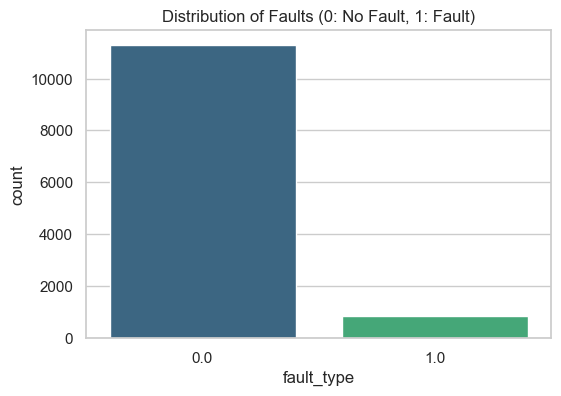

In [11]:
# 3. Target Variable Analysis (Fault Type)
plt.figure(figsize=(6, 4))
sns.countplot(x='fault_type', data=df, palette='viridis')
plt.title('Distribution of Faults (0: No Fault, 1: Fault)')
plt.savefig('fault_distribution.png')



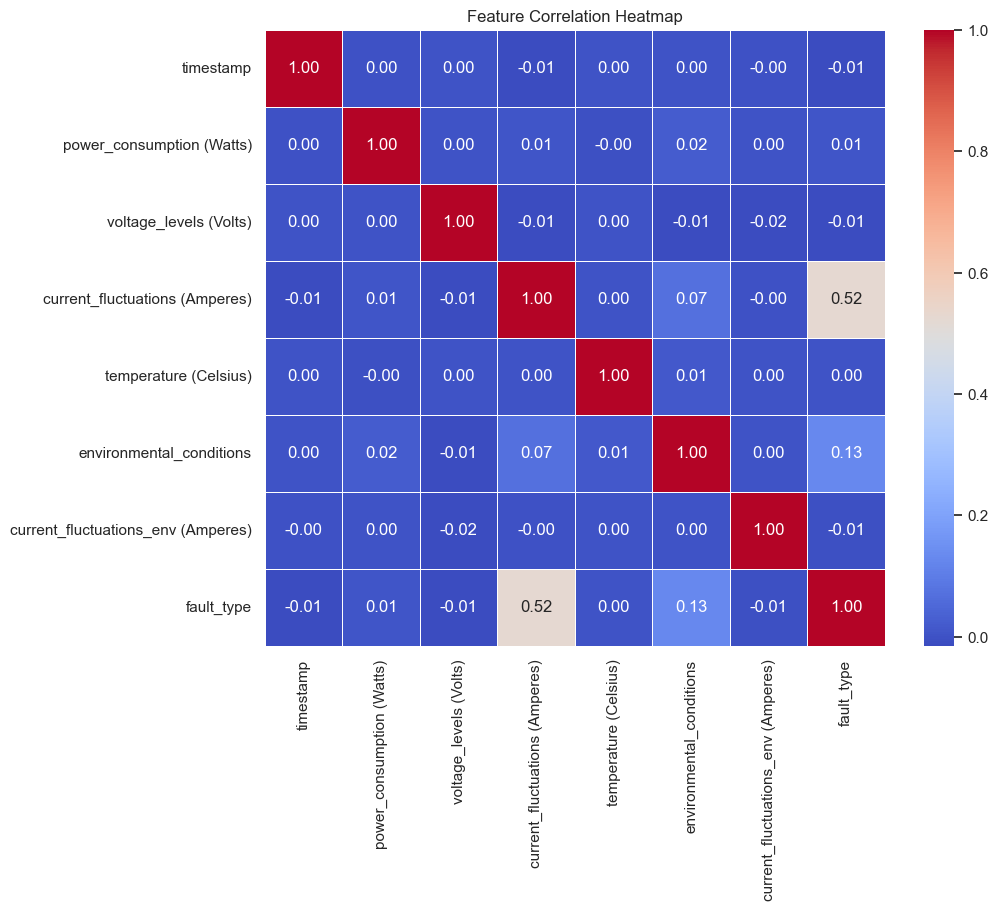

In [13]:
# 4. Correlation Analysis
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')



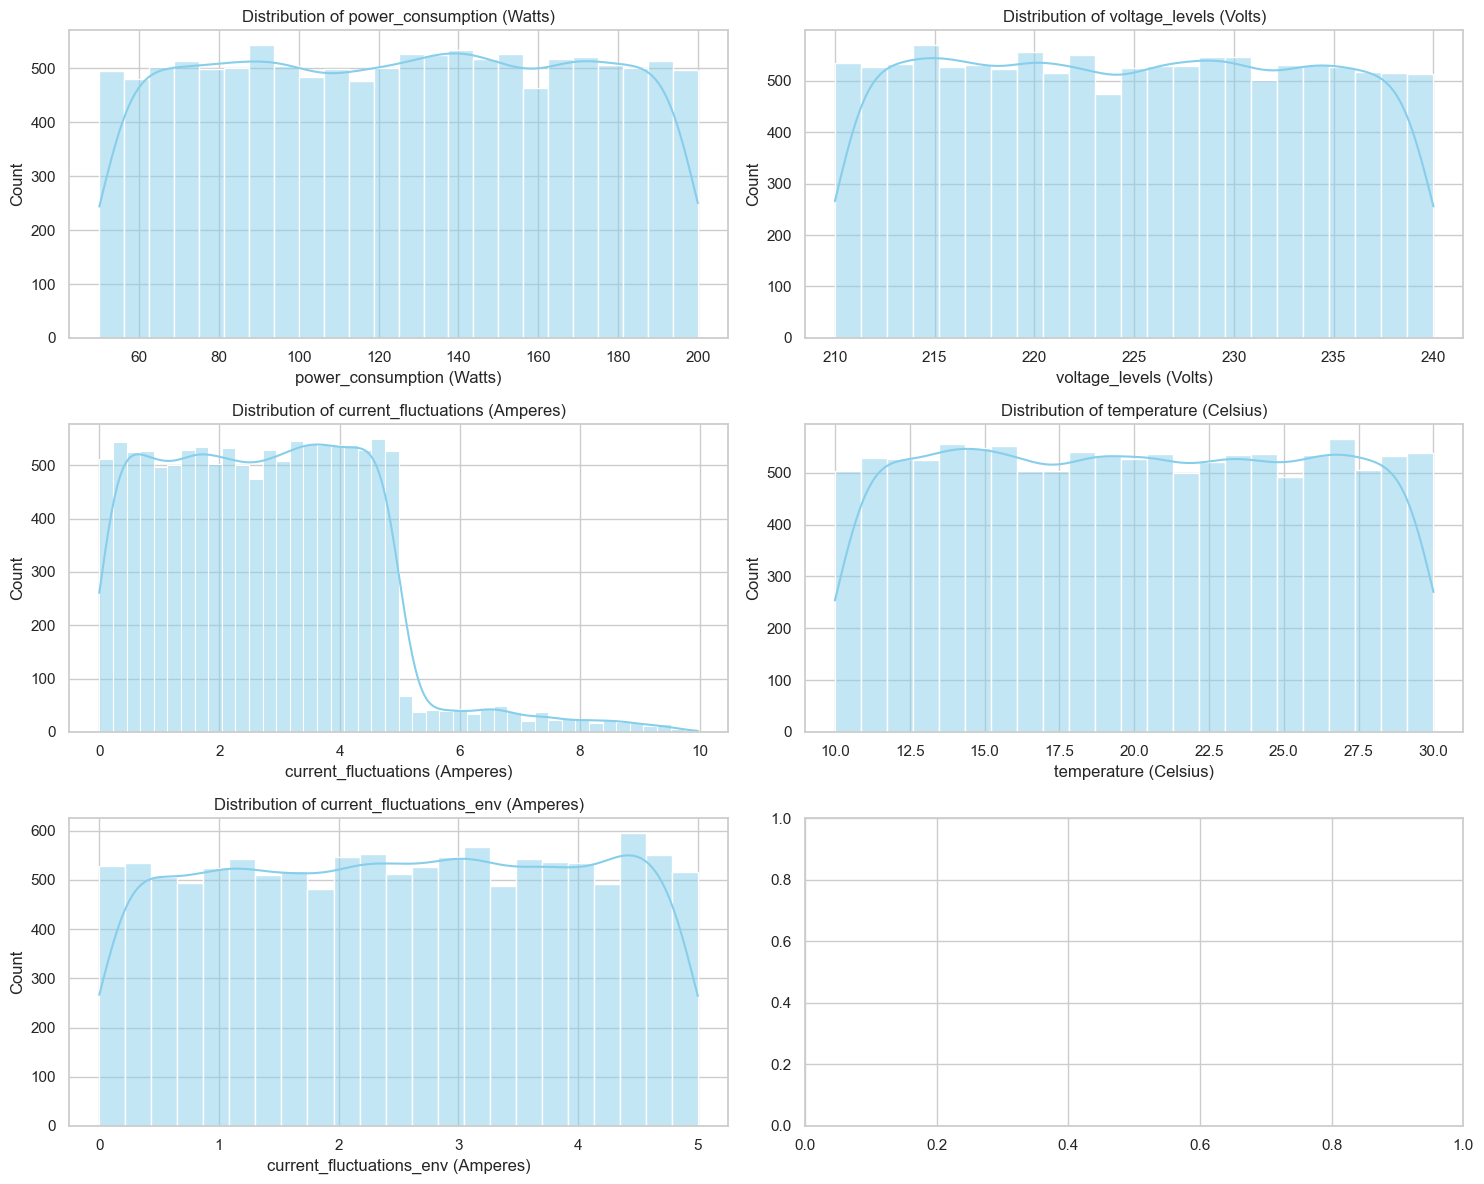

In [14]:
# 5. Univariate Analysis (Feature Distributions)
numerical_cols = ['power_consumption (Watts)', 'voltage_levels (Volts)', 
                  'current_fluctuations (Amperes)', 'temperature (Celsius)', 
                  'current_fluctuations_env (Amperes)']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig('numerical_distributions.png')



C:\Users\AMRETA\AppData\Local\Temp\ipykernel_18240\2354135152.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fault_type', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\AMRETA\AppData\Local\Temp\ipykernel_18240\2354135152.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fault_type', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\AMRETA\AppData\Local\Temp\ipykernel_18240\2354135152.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='fault_type', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\AMRETA\AppData\L

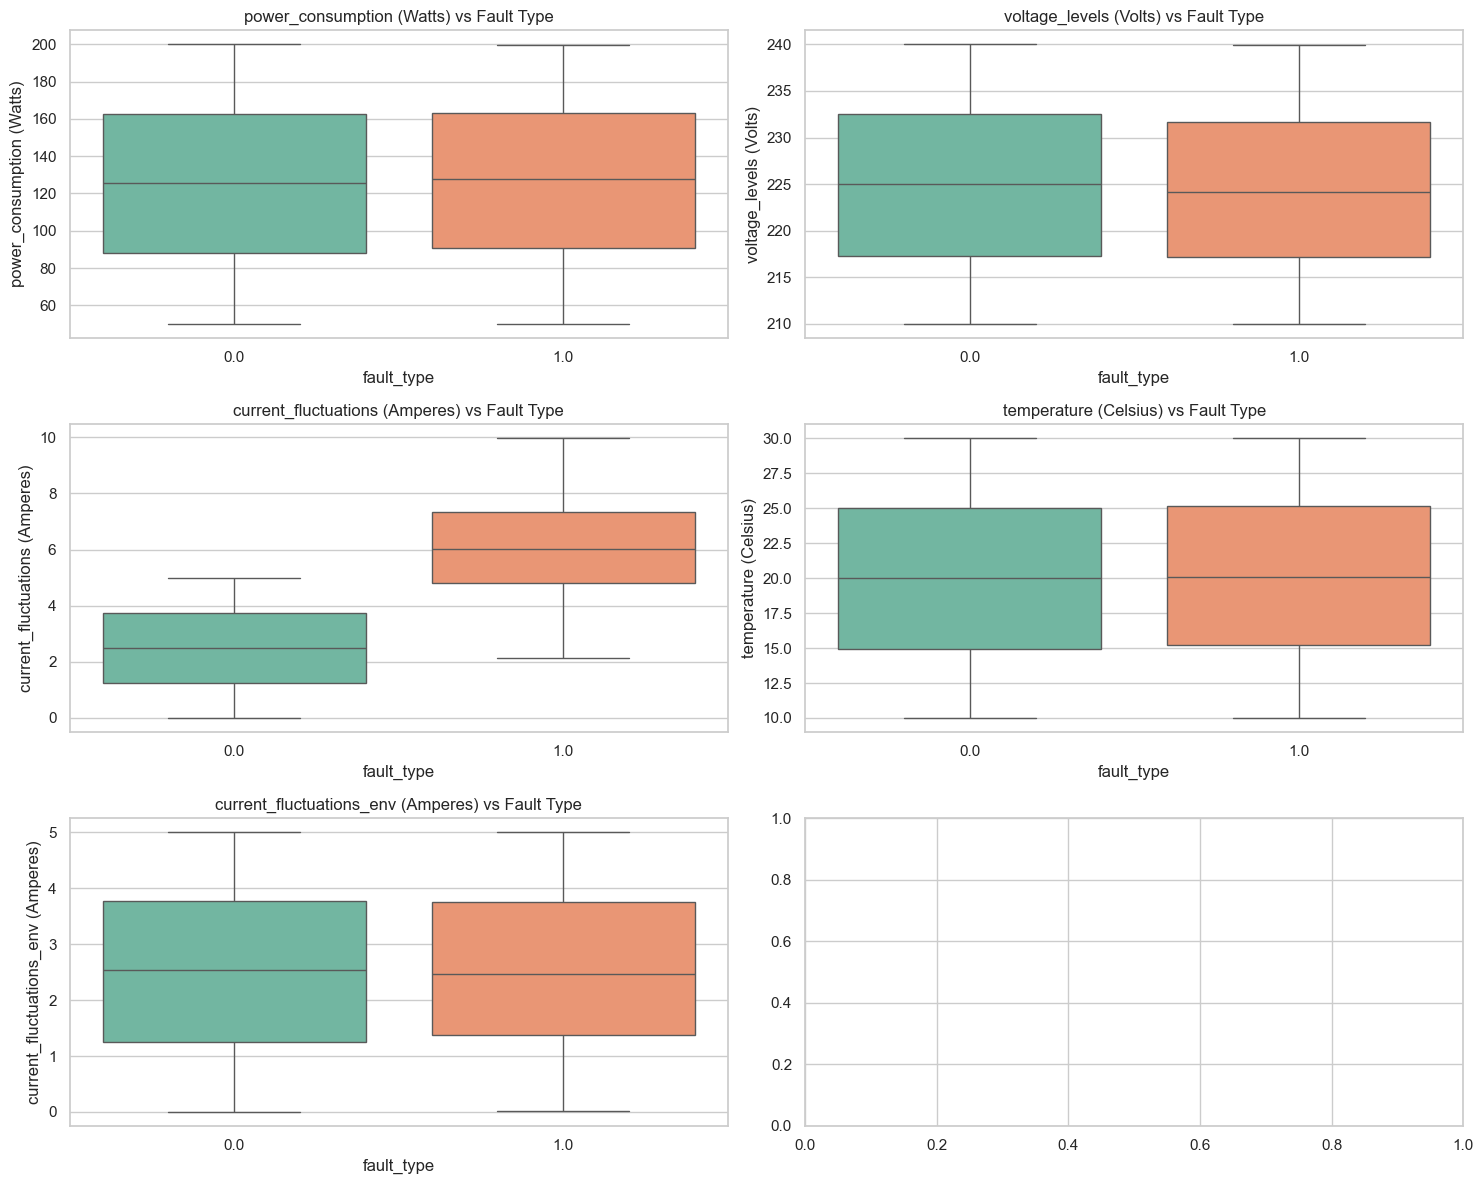

In [15]:
# 6. Bivariate Analysis (Impact of Features on Faults)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(x='fault_type', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Fault Type')
plt.tight_layout()
plt.savefig('features_vs_fault.png')

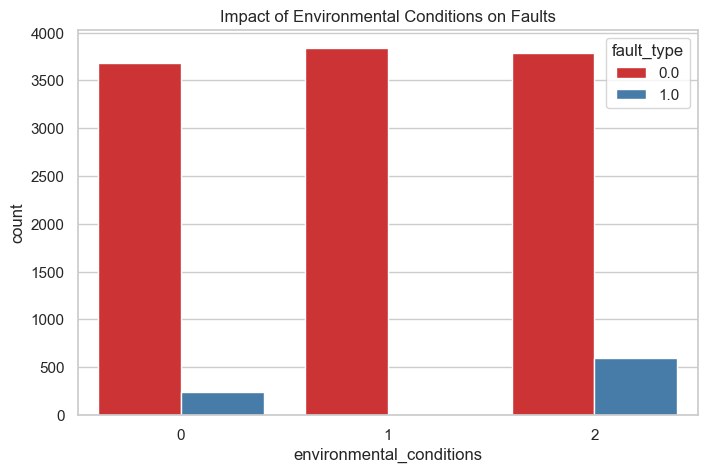

In [16]:
# 7. Categorical Analysis: Environmental Conditions
plt.figure(figsize=(8, 5))
sns.countplot(x='environmental_conditions', hue='fault_type', data=df, palette='Set1')
plt.title('Impact of Environmental Conditions on Faults')
plt.savefig('env_vs_fault.png')



EDA Completed. All plots saved.


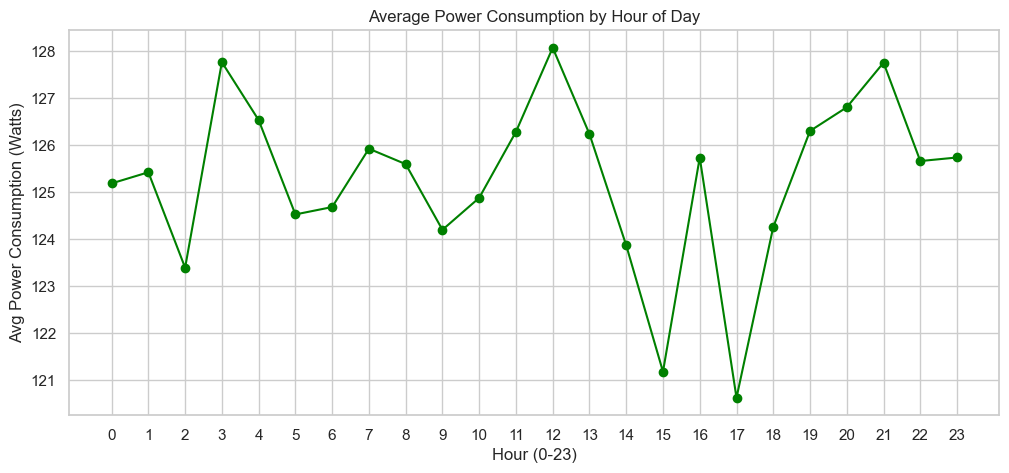

In [17]:
# 8. Time Series Analysis (Hourly Power Consumption)
plt.figure(figsize=(12, 5))
df.groupby('timestamp')['power_consumption (Watts)'].mean().plot(kind='line', marker='o', color='green')
plt.title('Average Power Consumption by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Avg Power Consumption (Watts)')
plt.xticks(range(0, 24))
plt.grid(True)
plt.savefig('time_vs_power.png')

print("\nEDA Completed. All plots saved.")